# 🤖 AI-Based Hiring Prediction System
### End-to-End Machine Learning Project | HR Analytics

---

**Project Goal:** Predict whether a candidate will be **Hired (1)** or **Rejected (0)** based on resume features like skills, experience, education, certifications, projects, and salary expectations.

**Dataset:** 1,000 synthetic resumes with 11 features  
**Model Techniques:** Logistic Regression, Random Forest, XGBoost, SVM, Neural Network  
**Evaluation:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix


## 📋 Table of Contents
1. [Install & Import Libraries](#1)
2. [Load Dataset](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Feature Engineering & Preprocessing](#4)
5. [Model Training — Multiple Algorithms](#5)
6. [Model Evaluation & Comparison](#6)
7. [Best Model — Detailed Analysis](#7)
8. [Feature Importance](#8)
9. [Hyperparameter Tuning](#9)
10. [Save & Deploy — Prediction Function](#10)


## 1. 📦 Install & Import Libraries

In [18]:
# Install required libraries
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn openpyxl -q
print("✅ All libraries installed successfully!")


✅ All libraries installed successfully!



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.pipeline import Pipeline

# Sklearn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# XGBoost
from xgboost import XGBClassifier

# Sklearn — Metrics
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score,
                              roc_curve, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

# Model Persistence
import pickle
import joblib

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. 📂 Load Dataset

In [20]:
df = pd.read_excel(r'C:\Users\hanaa\OneDrive\Desktop\GitHub\AI-Based Hiring Prediction System\hiring_project\AI-Based Hiring Prediction System1.csv.xlsx')
print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")


✅ Dataset loaded successfully!
📊 Shape: 1000 rows × 11 columns


In [21]:
# Preview the dataset
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df.head()


FIRST 5 ROWS


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [22]:
# Dataset Info
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Resume_ID               1000 non-null   int64
 1   Name                    1000 non-null   str  
 2   Skills                  1000 non-null   str  
 3   Experience (Years)      1000 non-null   int64
 4   Education               1000 non-null   str  
 5   Certifications          726 non-null    str  
 6   Job Role                1000 non-null   str  
 7   Recruiter Decision      1000 non-null   str  
 8   Salary Expectation ($)  1000 non-null   int64
 9   Projects Count          1000 non-null   int64
 10  AI Score (0-100)        1000 non-null   int64
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [23]:
# Statistical Summary
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe()


STATISTICAL SUMMARY


,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [24]:
# Check for missing values
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")

# Check class distribution
print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
dist = df['Recruiter Decision'].value_counts()
print(dist)
print(f"\nClass Balance: {(dist['Hire']/len(df)*100):.1f}% Hire | {(dist['Reject']/len(df)*100):.1f}% Reject")


MISSING VALUES
Certifications    274
dtype: int64

TARGET VARIABLE DISTRIBUTION
Recruiter Decision
Hire      812
Reject    188
Name: count, dtype: int64

Class Balance: 81.2% Hire | 18.8% Reject


## 3. 🔍 Exploratory Data Analysis (EDA)

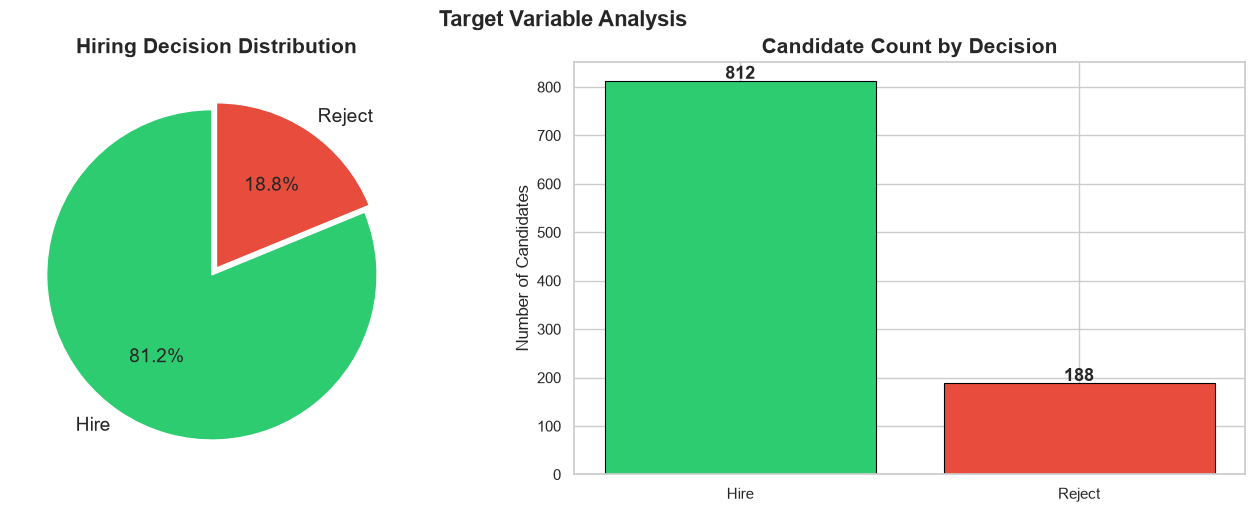

✅ Target distribution plotted


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Distribution — Pie
colors = ['#2ecc71', '#e74c3c']
counts = df['Recruiter Decision'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            textprops={'fontsize': 14}, explode=(0.05, 0))
axes[0].set_title('Hiring Decision Distribution', fontsize=15, fontweight='bold')

# Target Distribution — Bar
axes[1].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Candidate Count by Decision', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Number of Candidates')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.suptitle('Target Variable Analysis', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Target distribution plotted")


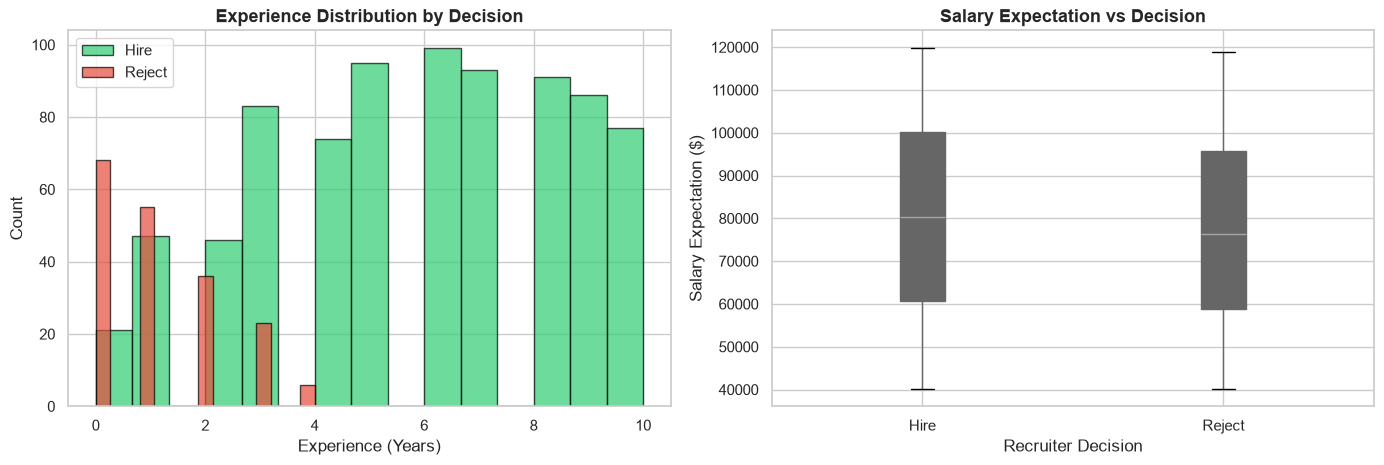

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Experience Distribution by Decision
for decision, color in zip(['Hire', 'Reject'], ['#2ecc71', '#e74c3c']):
    data = df[df['Recruiter Decision'] == decision]['Experience (Years)']
    axes[0].hist(data, bins=15, alpha=0.7, label=decision, color=color, edgecolor='black')
axes[0].set_title('Experience Distribution by Decision', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Experience (Years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Salary Expectation by Decision
df.boxplot(column='Salary Expectation ($)', by='Recruiter Decision',
           ax=axes[1], patch_artist=True)
axes[1].set_title('Salary Expectation vs Decision', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recruiter Decision')
axes[1].set_ylabel('Salary Expectation ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('numeric_features_eda.png', dpi=150, bbox_inches='tight')
plt.show()


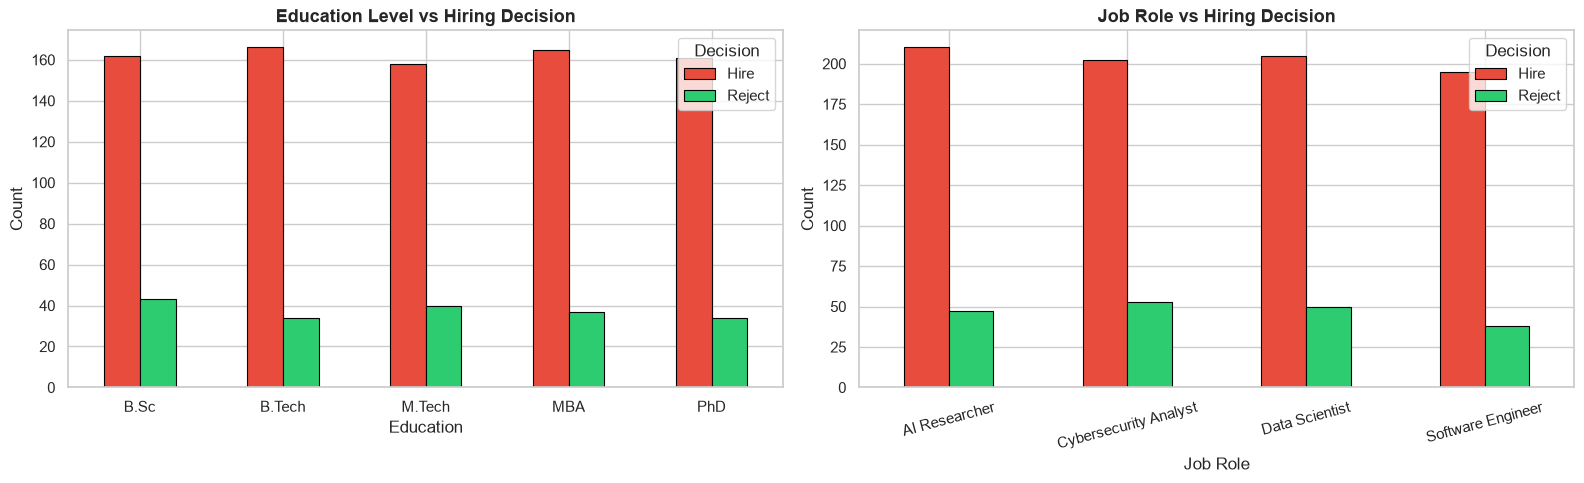

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Education vs Hiring Decision
edu_hire = df.groupby(['Education', 'Recruiter Decision']).size().unstack(fill_value=0)
edu_hire.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'],
              edgecolor='black', linewidth=0.8)
axes[0].set_title('Education Level vs Hiring Decision', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Count')
axes[0].legend(title='Decision')
axes[0].tick_params(axis='x', rotation=0)

# Job Role vs Hiring Decision
role_hire = df.groupby(['Job Role', 'Recruiter Decision']).size().unstack(fill_value=0)
role_hire.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'],
               edgecolor='black', linewidth=0.8)
axes[1].set_title('Job Role vs Hiring Decision', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Job Role')
axes[1].set_ylabel('Count')
axes[1].legend(title='Decision')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('categorical_eda.png', dpi=150, bbox_inches='tight')
plt.show()


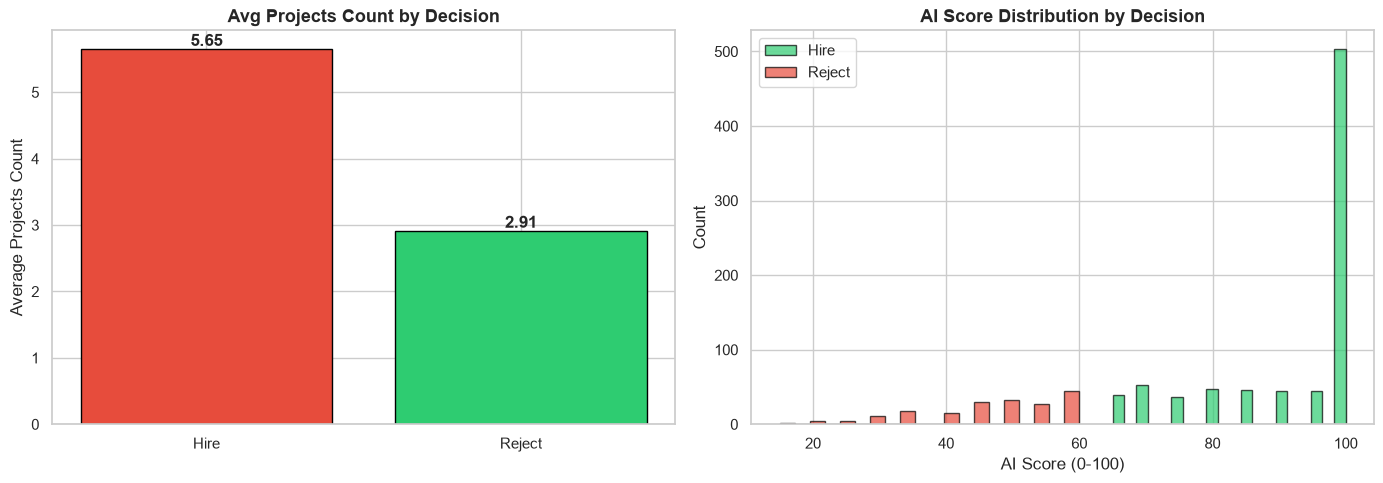

In [28]:
# Projects Count & AI Score Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Projects Count
proj_avg = df.groupby('Recruiter Decision')['Projects Count'].mean()
bars = axes[0].bar(proj_avg.index, proj_avg.values,
                   color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Avg Projects Count by Decision', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Projects Count')
for bar, val in zip(bars, proj_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontweight='bold')

# AI Score Distribution
for decision, color in zip(['Hire', 'Reject'], ['#2ecc71', '#e74c3c']):
    data = df[df['Recruiter Decision'] == decision]['AI Score (0-100)']
    axes[1].hist(data, bins=20, alpha=0.7, label=decision, color=color, edgecolor='black')
axes[1].set_title('AI Score Distribution by Decision', fontsize=13, fontweight='bold')
axes[1].set_xlabel('AI Score (0-100)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('projects_aiscore_eda.png', dpi=150, bbox_inches='tight')
plt.show()


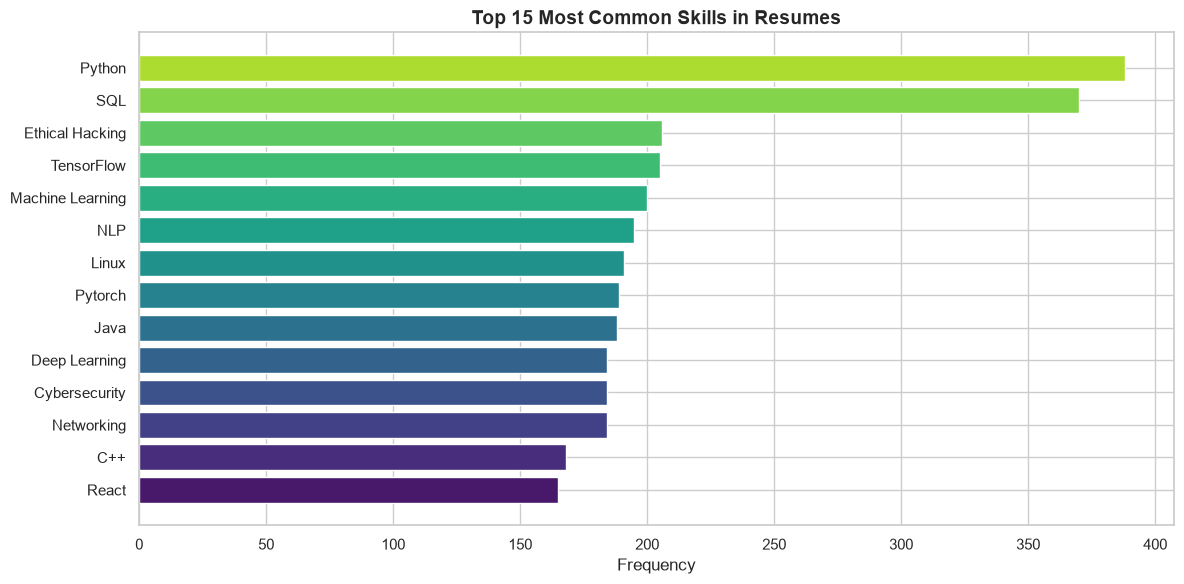


📊 Total unique skills found: 14


In [29]:
# Skills Analysis
from collections import Counter

all_skills = []
for skills_str in df['Skills']:
    skills = [s.strip() for s in str(skills_str).split(',')]
    all_skills.extend(skills)

skill_counts = Counter(all_skills)
top_skills = pd.DataFrame(skill_counts.most_common(15),
                           columns=['Skill', 'Count'])

plt.figure(figsize=(12, 6))
bars = plt.barh(top_skills['Skill'][::-1], top_skills['Count'][::-1],
                color=sns.color_palette('viridis', 15))
plt.title('Top 15 Most Common Skills in Resumes', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('top_skills.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📊 Total unique skills found: {len(skill_counts)}")


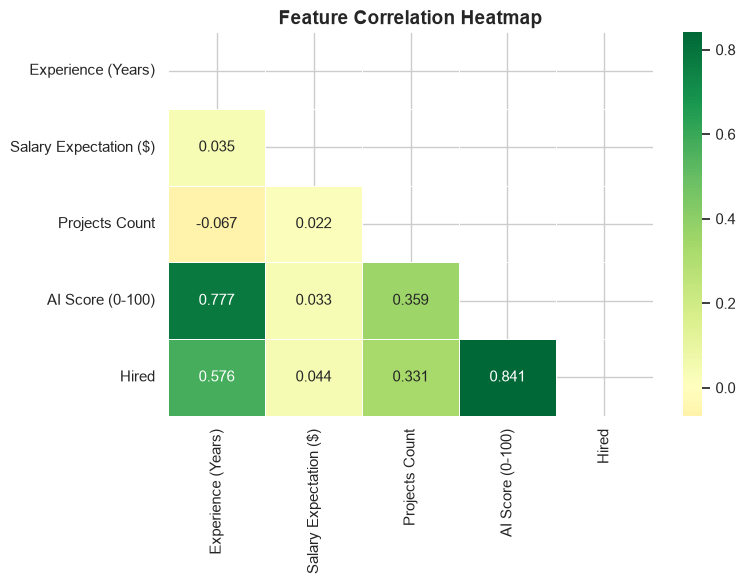

In [30]:
# Correlation Heatmap (Numeric Features)
numeric_cols = ['Experience (Years)', 'Salary Expectation ($)',
                'Projects Count', 'AI Score (0-100)']

# Encode target temporarily for correlation
df_corr = df[numeric_cols].copy()
df_corr['Hired'] = (df['Recruiter Decision'] == 'Hire').astype(int)

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, mask=mask,
            annot_kws={'size': 11})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. ⚙️ Feature Engineering & Preprocessing

In [31]:
# ── Step 1: Encode Target Variable ──────────────────────────────────────
df['Target'] = (df['Recruiter Decision'] == 'Hire').astype(int)
print("Target encoding:")
print(df['Target'].value_counts())
print(f"  1 = Hire | 0 = Reject")


Target encoding:
Target
1    812
0    188
Name: count, dtype: int64
  1 = Hire | 0 = Reject


In [32]:
# ── Step 2: Skills Feature Engineering ──────────────────────────────────
# Extract top skills and create binary columns

# Get top-N skills
skill_freq = Counter(all_skills)
TOP_N = 20
top_skill_list = [skill for skill, _ in skill_freq.most_common(TOP_N)]

print(f"Top {TOP_N} skills selected for feature engineering:")
for i, skill in enumerate(top_skill_list, 1):
    print(f"  {i:2d}. {skill}")


Top 20 skills selected for feature engineering:
   1. Python
   2. SQL
   3. Ethical Hacking
   4. TensorFlow
   5. Machine Learning
   6. NLP
   7. Linux
   8. Pytorch
   9. Java
  10. Deep Learning
  11. Cybersecurity
  12. Networking
  13. C++
  14. React


In [33]:
# Create binary skill features
for skill in top_skill_list:
    col_name = f'skill_{skill.replace(" ", "_").replace("-", "_")}'
    df[col_name] = df['Skills'].apply(
        lambda x: 1 if skill.lower() in str(x).lower() else 0
    )

# Count total skills
df['Total_Skills_Count'] = df['Skills'].apply(
    lambda x: len([s.strip() for s in str(x).split(',')])
)

print(f"✅ Created {TOP_N} binary skill features + Total_Skills_Count")
print(f"   Dataset shape: {df.shape}")


✅ Created 20 binary skill features + Total_Skills_Count
   Dataset shape: (1000, 27)


In [34]:
# ── Step 3: Encode Categorical Variables ─────────────────────────────────
le_edu = LabelEncoder()
le_cert = LabelEncoder()
le_role = LabelEncoder()

df['Education_Enc']    = le_edu.fit_transform(df['Education'])
df['Certifications_Enc'] = le_cert.fit_transform(df['Certifications'])
df['Job_Role_Enc']     = le_role.fit_transform(df['Job Role'])

print("✅ Label encoding complete:")
print(f"  Education classes    : {list(le_edu.classes_)}")
print(f"  Certification classes: {list(le_cert.classes_)}")
print(f"  Job Role classes     : {list(le_role.classes_)}")


✅ Label encoding complete:
  Education classes    : ['B.Sc', 'B.Tech', 'M.Tech', 'MBA', 'PhD']
  Certification classes: ['AWS Certified', 'Deep Learning Specialization', 'Google ML', nan]
  Job Role classes     : ['AI Researcher', 'Cybersecurity Analyst', 'Data Scientist', 'Software Engineer']


In [35]:
# ── Step 4: Build Feature Matrix ─────────────────────────────────────────
numeric_features    = ['Experience (Years)', 'Salary Expectation ($)',
                        'Projects Count', 'AI Score (0-100)', 'Total_Skills_Count']
categorical_features = ['Education_Enc', 'Certifications_Enc', 'Job_Role_Enc']
skill_features       = [c for c in df.columns if c.startswith('skill_')]

feature_cols = numeric_features + categorical_features + skill_features

X = df[feature_cols]
y = df['Target']

print(f"✅ Feature matrix built:")
print(f"   Total features      : {len(feature_cols)}")
print(f"   Numeric features    : {len(numeric_features)}")
print(f"   Categorical features: {len(categorical_features)}")
print(f"   Skill features      : {len(skill_features)}")
print(f"   X shape: {X.shape} | y shape: {y.shape}")


✅ Feature matrix built:
   Total features      : 22
   Numeric features    : 5
   Categorical features: 3
   Skill features      : 14
   X shape: (1000, 22) | y shape: (1000,)


In [36]:
# ── Step 5: Train-Test Split ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Data split complete (80/20 stratified):")
print(f"   Training set : {X_train.shape[0]} samples")
print(f"   Test set     : {X_test.shape[0]} samples")
print(f"\nClass distribution (Train):")
print(pd.Series(y_train).value_counts().rename({1:'Hire', 0:'Reject'}))
print(f"\nClass distribution (Test):")
print(pd.Series(y_test).value_counts().rename({1:'Hire', 0:'Reject'}))


✅ Data split complete (80/20 stratified):
   Training set : 800 samples
   Test set     : 200 samples

Class distribution (Train):
Target
Hire      650
Reject    150
Name: count, dtype: int64

Class distribution (Test):
Target
Hire      162
Reject     38
Name: count, dtype: int64


## 5. 🧠 Model Training — Multiple Algorithms

In [37]:
# Define all models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost'              : XGBClassifier(n_estimators=200, random_state=42,
                                           eval_metric='logloss', verbosity=0),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM'                  : SVC(probability=True, random_state=42),
    'K-Nearest Neighbors'  : KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes'          : GaussianNB(),
}

print(f"✅ {len(models)} models initialized and ready for training!")


✅ 7 models initialized and ready for training!


In [38]:
# Train all models and collect results
results = {}
trained_models = {}

print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>7} {'AUC':>7}")
print("=" * 65)

for name, model in models.items():
    # Use scaled data for distance-based models
    if name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    results[name] = {'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1, 'AUC-ROC': auc}
    trained_models[name] = (model, y_pred, y_prob)

    print(f"{name:<25} {acc:>8.4f}  {prec:>9.4f}  {rec:>7.4f}  {f1:>6.4f}  {auc:>6.4f}")

print("=" * 65)
print("✅ All models trained and evaluated!")


Model                      Accuracy  Precision   Recall      F1     AUC
Logistic Regression         0.9950     1.0000   0.9938  0.9969  0.9998
Random Forest               1.0000     1.0000   1.0000  1.0000  1.0000
XGBoost                     1.0000     1.0000   1.0000  1.0000  1.0000
Gradient Boosting           1.0000     1.0000   1.0000  1.0000  1.0000
SVM                         0.9650     0.9874   0.9691  0.9782  0.9953
K-Nearest Neighbors         0.9250     0.9249   0.9877  0.9552  0.9681
Naive Bayes                 0.9500     1.0000   0.9383  0.9682  1.0000
✅ All models trained and evaluated!


## 6. 📊 Model Evaluation & Comparison

In [39]:
results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
print("Model Rankings (sorted by F1-Score):")
print(results_df.to_string())


Model Rankings (sorted by F1-Score):
                     Accuracy  Precision    Recall  F1-Score   AUC-ROC
Random Forest           1.000   1.000000  1.000000  1.000000  1.000000
XGBoost                 1.000   1.000000  1.000000  1.000000  1.000000
Gradient Boosting       1.000   1.000000  1.000000  1.000000  1.000000
Logistic Regression     0.995   1.000000  0.993827  0.996904  0.999838
SVM                     0.965   0.987421  0.969136  0.978193  0.995289
Naive Bayes             0.950   1.000000  0.938272  0.968153  1.000000
K-Nearest Neighbors     0.925   0.924855  0.987654  0.955224  0.968080


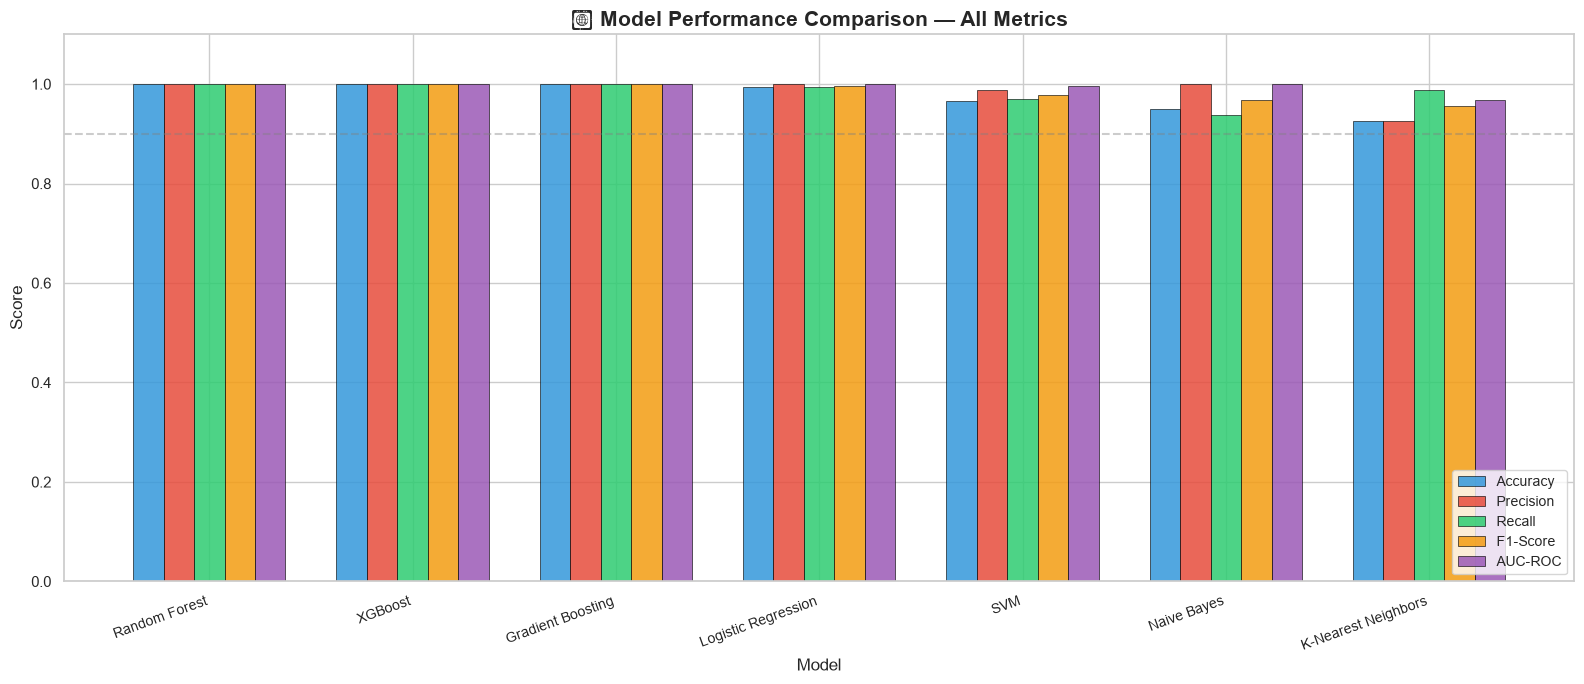

In [40]:
# Visual comparison of all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.15
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(16, 7))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('📊 Model Performance Comparison — All Metrics', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=10)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4, label='0.90 baseline')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


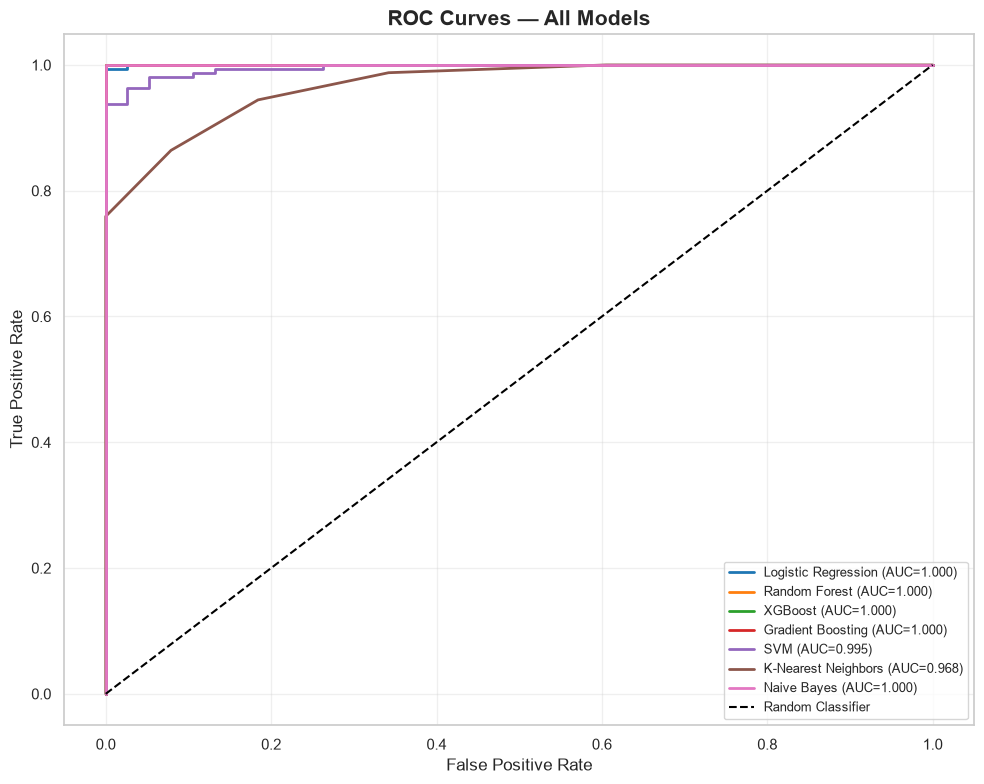

In [41]:
# ROC Curves for all models
plt.figure(figsize=(10, 8))
colors_roc = sns.color_palette('tab10', len(trained_models))

for (name, (model, y_pred, y_prob)), color in zip(trained_models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


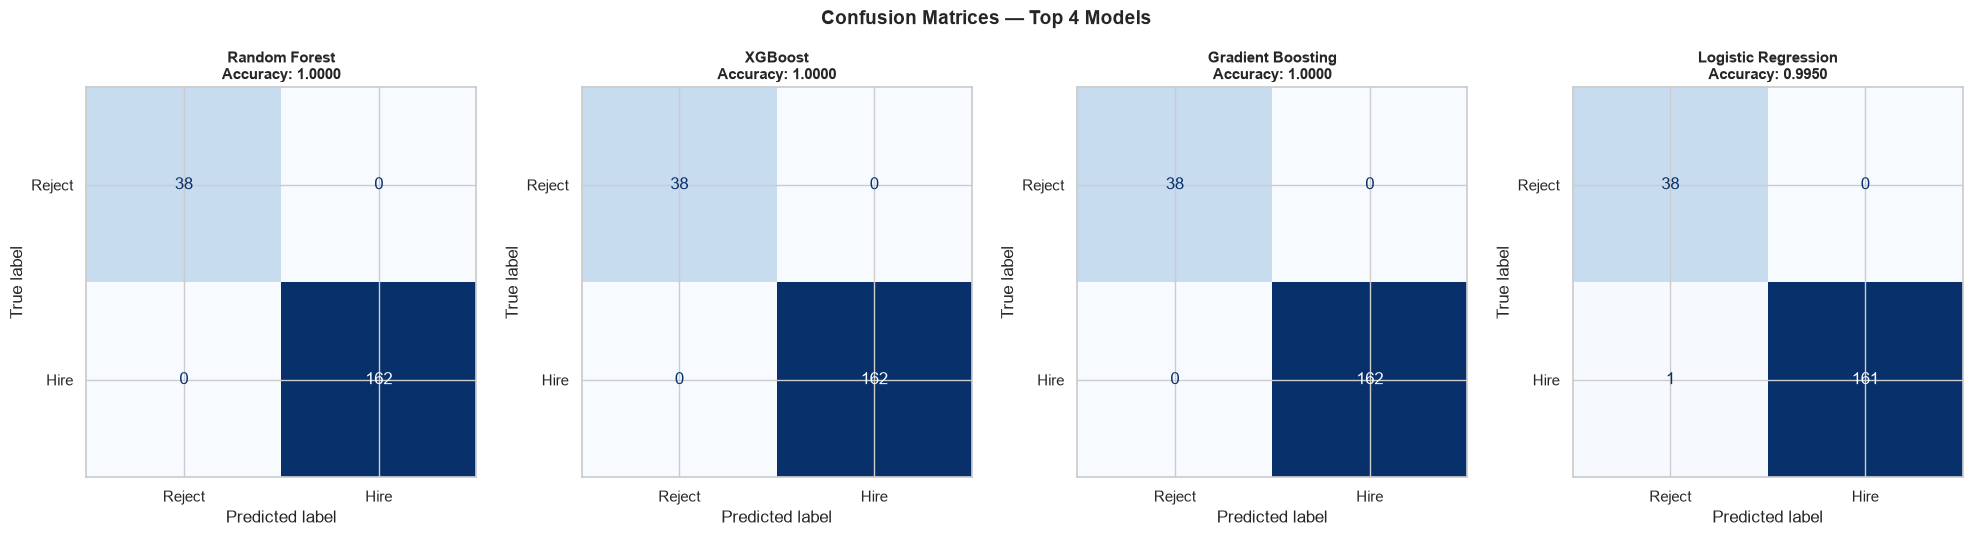

In [42]:
# Confusion matrices for top 4 models
top4 = results_df.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, name in zip(axes, top4):
    _, y_pred, _ = trained_models[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Reject', 'Hire'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = results[name]['Accuracy']
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — Top 4 Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. 🏆 Best Model — Detailed Analysis

In [43]:
best_model_name = results_df.index[0]
best_model, best_y_pred, best_y_prob = trained_models[best_model_name]

print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*50}")
print(f"\n📋 Full Classification Report:")
print(classification_report(y_test, best_y_pred,
                             target_names=['Reject (0)', 'Hire (1)']))

print(f"\n📊 Summary Metrics:")
for metric, val in results[best_model_name].items():
    print(f"   {metric:<15}: {val:.4f}")


🏆 BEST MODEL: Random Forest

📋 Full Classification Report:
              precision    recall  f1-score   support

  Reject (0)       1.00      1.00      1.00        38
    Hire (1)       1.00      1.00      1.00       162

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


📊 Summary Metrics:
   Accuracy       : 1.0000
   Precision      : 1.0000
   Recall         : 1.0000
   F1-Score       : 1.0000
   AUC-ROC        : 1.0000


In [44]:
# Cross-Validation for best model (5-fold Stratified)
print(f"🔄 Running 5-Fold Stratified Cross-Validation for {best_model_name}...")

# Use appropriate feature set
if best_model_name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors']:
    X_cv = scaler.transform(X)
else:
    X_cv = X.values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Re-instantiate a fresh model for CV
fresh_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=200, random_state=42,
                                           eval_metric='logloss', verbosity=0),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes'         : GaussianNB(),
}
cv_model = fresh_models[best_model_name]

cv_acc = cross_val_score(cv_model, X_cv, y, cv=cv, scoring='accuracy')
cv_f1  = cross_val_score(cv_model, X_cv, y, cv=cv, scoring='f1')
cv_auc = cross_val_score(cv_model, X_cv, y, cv=cv, scoring='roc_auc')

print(f"\n  Metric       |  Mean   |  Std    |  Scores")
print(f"  {'-'*55}")
print(f"  Accuracy     | {cv_acc.mean():.4f}  | {cv_acc.std():.4f}  | {np.round(cv_acc, 4)}")
print(f"  F1-Score     | {cv_f1.mean():.4f}  | {cv_f1.std():.4f}  | {np.round(cv_f1, 4)}")
print(f"  AUC-ROC      | {cv_auc.mean():.4f}  | {cv_auc.std():.4f}  | {np.round(cv_auc, 4)}")


🔄 Running 5-Fold Stratified Cross-Validation for Random Forest...

  Metric       |  Mean   |  Std    |  Scores
  -------------------------------------------------------
  Accuracy     | 1.0000  | 0.0000  | [1. 1. 1. 1. 1.]
  F1-Score     | 1.0000  | 0.0000  | [1. 1. 1. 1. 1.]
  AUC-ROC      | 1.0000  | 0.0000  | [1. 1. 1. 1. 1.]


## 8. 🔑 Feature Importance Analysis

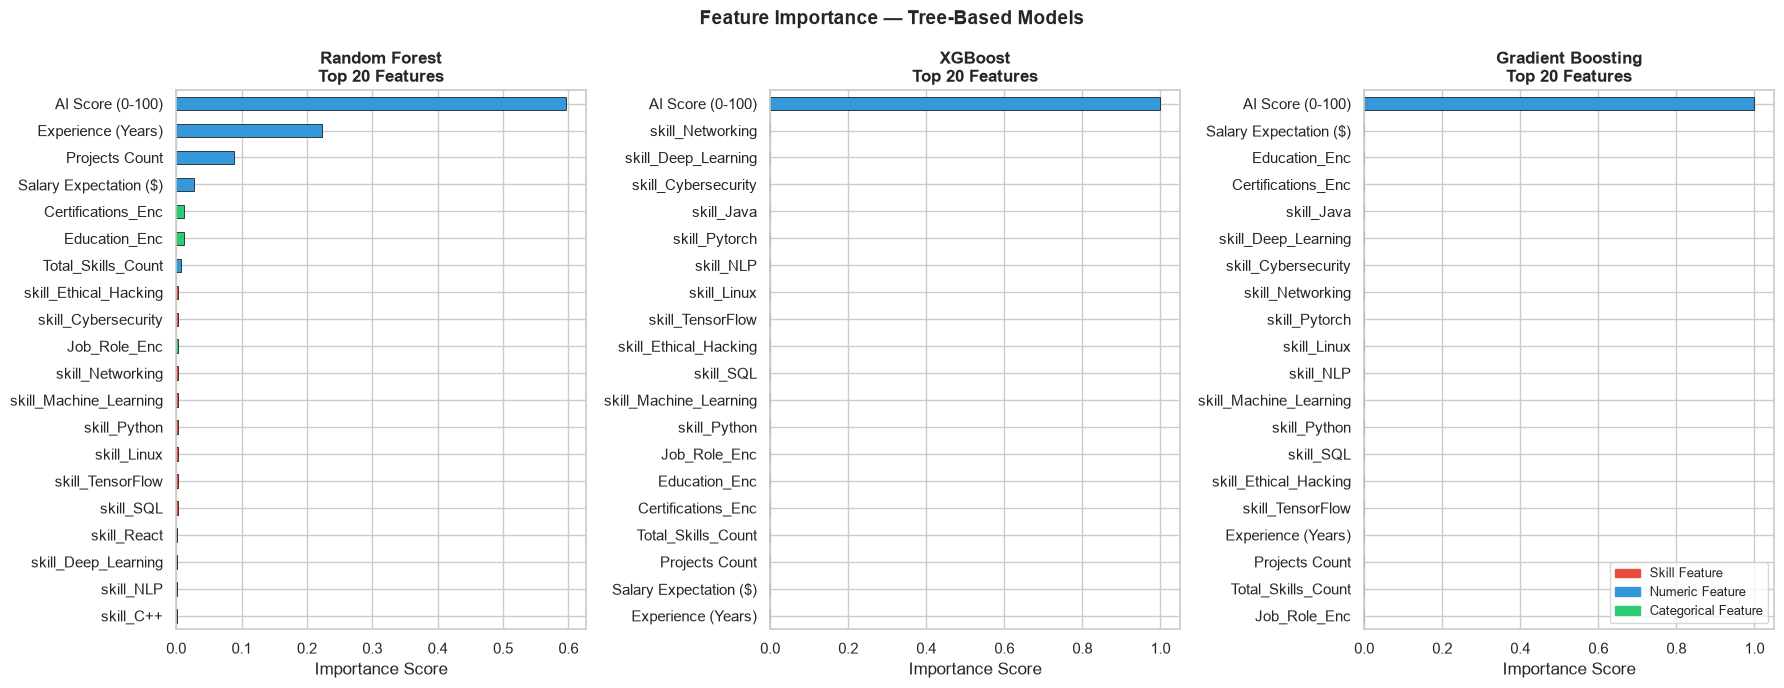

In [45]:
# Get feature importance from tree-based models
tree_models = {k: v for k, v in trained_models.items()
               if k in ['Random Forest', 'XGBoost', 'Gradient Boosting']}

fig, axes = plt.subplots(1, len(tree_models), figsize=(18, 7))

for ax, (name, (model, _, _)) in zip(axes, tree_models.items()):
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    top20 = importances.nlargest(20).sort_values()

    colors_fi = ['#e74c3c' if 'skill' in i else '#3498db' if i in numeric_features
                 else '#2ecc71' for i in top20.index]
    top20.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{name}\nTop 20 Features', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

# Legend
red_p   = mpatches.Patch(color='#e74c3c', label='Skill Feature')
blue_p  = mpatches.Patch(color='#3498db', label='Numeric Feature')
green_p = mpatches.Patch(color='#2ecc71', label='Categorical Feature')
plt.legend(handles=[red_p, blue_p, green_p], loc='lower right',
           bbox_to_anchor=(1, 0), fontsize=9)

plt.suptitle('Feature Importance — Tree-Based Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [46]:
# Combined feature importance (average of tree models)
all_imp = pd.DataFrame({
    name: pd.Series(model.feature_importances_, index=feature_cols)
    for name, (model, _, _) in tree_models.items()
})
avg_imp = all_imp.mean(axis=1).sort_values(ascending=False)

print("🏅 Top 20 Most Important Features (Averaged across tree models):")
print("=" * 55)
for rank, (feat, score) in enumerate(avg_imp.head(20).items(), 1):
    bar = '█' * int(score * 500)
    print(f"{rank:2d}. {feat:<35} {score:.5f}  {bar}")


🏅 Top 20 Most Important Features (Averaged across tree models):
 1. AI Score (0-100)                    0.86566  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
 2. Experience (Years)                  0.07453  █████████████████████████████████████
 3. Projects Count                      0.02955  ██████████████
 4. Salary Expectation ($)              0.00927  ████
 5. Certifications_Enc                  0.00396  █
 6. Education_Enc                       0.00387  █
 7. Total_Skills_Count                  0.00266  █
 8. skill_Ethical_Hacking               0.00103  
 9. skill_Cybersecurity                 0.0008

## 9. 🔧 Hyperparameter Tuning (Best Model)

In [47]:
# Hyperparameter Tuning for Random Forest (modify as needed)
print("🔧 Running GridSearchCV for Random Forest...")
print("   (This may take 2-3 minutes...)")

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
}

rf_tuning = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
rf_tuning.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {rf_tuning.best_params_}")
print(f"   Best CV F1-Score: {rf_tuning.best_score_:.4f}")

# Evaluate tuned model
y_pred_tuned = rf_tuning.best_estimator_.predict(X_test)
y_prob_tuned = rf_tuning.best_estimator_.predict_proba(X_test)[:, 1]

print(f"\n📊 Tuned Model Test Performance:")
print(f"   Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"   F1-Score  : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"   AUC-ROC   : {roc_auc_score(y_test, y_prob_tuned):.4f}")


🔧 Running GridSearchCV for Random Forest...
   (This may take 2-3 minutes...)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
   Best CV F1-Score: 1.0000

📊 Tuned Model Test Performance:
   Accuracy  : 1.0000
   F1-Score  : 1.0000
   AUC-ROC   : 1.0000


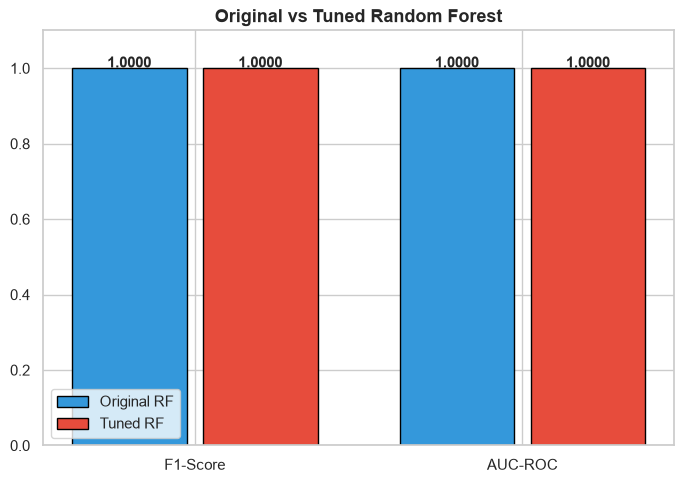

In [48]:
# Compare tuned vs original
orig_rf_f1   = results['Random Forest']['F1-Score']
tuned_rf_f1  = f1_score(y_test, y_pred_tuned)
orig_rf_auc  = results['Random Forest']['AUC-ROC']
tuned_rf_auc = roc_auc_score(y_test, y_prob_tuned)

labels = ['F1-Score', 'AUC-ROC']
orig  = [orig_rf_f1, orig_rf_auc]
tuned = [tuned_rf_f1, tuned_rf_auc]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - 0.2, orig, 0.35, label='Original RF', color='#3498db',
               edgecolor='black')
bars2 = ax.bar(x + 0.2, tuned, 0.35, label='Tuned RF', color='#e74c3c',
               edgecolor='black')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_title('Original vs Tuned Random Forest', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. 💾 Save Model & Prediction Function

In [49]:
# Select the best overall model (tuned RF)
final_model = rf_tuning.best_estimator_

# Save model and scaler
joblib.dump(final_model, 'hiring_prediction_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump({
    'feature_cols'   : feature_cols,
    'top_skill_list' : top_skill_list,
    'le_edu'         : le_edu,
    'le_cert'        : le_cert,
    'le_role'        : le_role,
}, 'model_metadata.pkl')

print("✅ Model artifacts saved:")
print("   hiring_prediction_model.pkl")
print("   feature_scaler.pkl")
print("   model_metadata.pkl")


✅ Model artifacts saved:
   hiring_prediction_model.pkl
   feature_scaler.pkl
   model_metadata.pkl


In [50]:
# ── Prediction Function ──────────────────────────────────────────────────────
def predict_hiring(
    experience_years: float,
    education: str,           # 'B.Sc' | 'B.Tech' | 'MBA' | 'M.Tech' | 'PhD'
    certifications: str,      # 'AWS Certified' | 'Deep Learning Specialization' | 'Google ML'
    job_role: str,            # 'Data Scientist' | 'AI Researcher' | 'Software Engineer' | 'Cybersecurity Analyst'
    salary_expectation: float,
    projects_count: int,
    ai_score: float,
    skills: str,              # Comma-separated, e.g. "Python, SQL, TensorFlow"
    verbose: bool = True
) -> dict:
    """
    Predict hiring decision for a candidate.

    Returns:
        dict with 'decision', 'confidence', 'hire_probability', 'reject_probability'
    """
    # Load metadata
    meta = joblib.load('model_metadata.pkl')
    model  = joblib.load('hiring_prediction_model.pkl')

    # Build skill features
    skill_features_vec = {}
    for skill in meta['top_skill_list']:
        col = f'skill_{skill.replace(" ", "_").replace("-", "_")}'
        skill_features_vec[col] = 1 if skill.lower() in skills.lower() else 0

    total_skills = len([s.strip() for s in skills.split(',')])

    # Encode categoricals
    edu_enc  = meta['le_edu'].transform([education])[0]
    cert_enc = meta['le_cert'].transform([certifications])[0]
    role_enc = meta['le_role'].transform([job_role])[0]

    # Assemble feature vector
    row = {
        'Experience (Years)'   : experience_years,
        'Salary Expectation ($)': salary_expectation,
        'Projects Count'       : projects_count,
        'AI Score (0-100)'     : ai_score,
        'Total_Skills_Count'   : total_skills,
        'Education_Enc'        : edu_enc,
        'Certifications_Enc'   : cert_enc,
        'Job_Role_Enc'         : role_enc,
        **skill_features_vec
    }
    X_input = pd.DataFrame([row])[meta['feature_cols']]

    # Predict
    prob  = model.predict_proba(X_input)[0]
    pred  = model.predict(X_input)[0]

    result = {
        'decision'           : '✅ HIRE' if pred == 1 else '❌ REJECT',
        'hire_probability'   : round(prob[1], 4),
        'reject_probability' : round(prob[0], 4),
        'confidence'         : round(max(prob) * 100, 2),
    }

    if verbose:
        print("=" * 50)
        print("🤖 AI HIRING PREDICTION RESULT")
        print("=" * 50)
        print(f"  Decision           : {result['decision']}")
        print(f"  Hire Probability   : {result['hire_probability']:.2%}")
        print(f"  Reject Probability : {result['reject_probability']:.2%}")
        print(f"  Model Confidence   : {result['confidence']}%")
        print("=" * 50)

    return result

print("✅ predict_hiring() function is ready!")


✅ predict_hiring() function is ready!


In [51]:
# ── Test with Sample Candidates ──────────────────────────────────────────────

print("\n🧑‍💻 CANDIDATE 1 — Senior Data Scientist")
print("-" * 50)
result1 = predict_hiring(
    experience_years   = 8,
    education          = 'PhD',
    certifications     = 'Deep Learning Specialization',
    job_role           = 'Data Scientist',
    salary_expectation = 95000,
    projects_count     = 12,
    ai_score           = 88,
    skills             = 'Python, TensorFlow, Machine Learning, SQL, Pytorch'
)

print("\n🧑‍💻 CANDIDATE 2 — Fresh Graduate")
print("-" * 50)
result2 = predict_hiring(
    experience_years   = 0,
    education          = 'B.Sc',
    certifications     = 'AWS Certified',
    job_role           = 'Software Engineer',
    salary_expectation = 120000,
    projects_count     = 1,
    ai_score           = 40,
    skills             = 'Java'
)

print("\n🧑‍💻 CANDIDATE 3 — Mid-level AI Researcher")
print("-" * 50)
result3 = predict_hiring(
    experience_years   = 5,
    education          = 'M.Tech',
    certifications     = 'Google ML',
    job_role           = 'AI Researcher',
    salary_expectation = 80000,
    projects_count     = 7,
    ai_score           = 75,
    skills             = 'NLP, TensorFlow, Python, Deep Learning'
)



🧑‍💻 CANDIDATE 1 — Senior Data Scientist
--------------------------------------------------
🤖 AI HIRING PREDICTION RESULT
  Decision           : ✅ HIRE
  Hire Probability   : 100.00%
  Reject Probability : 0.00%
  Model Confidence   : 100.0%

🧑‍💻 CANDIDATE 2 — Fresh Graduate
--------------------------------------------------
🤖 AI HIRING PREDICTION RESULT
  Decision           : ❌ REJECT
  Hire Probability   : 8.00%
  Reject Probability : 92.00%
  Model Confidence   : 92.0%

🧑‍💻 CANDIDATE 3 — Mid-level AI Researcher
--------------------------------------------------
🤖 AI HIRING PREDICTION RESULT
  Decision           : ✅ HIRE
  Hire Probability   : 100.00%
  Reject Probability : 0.00%
  Model Confidence   : 100.0%


In [52]:
# ── Final Summary Dashboard ──────────────────────────────────────────────────
print("\n" + "=" * 65)
print("🎯  FINAL PROJECT SUMMARY — AI-Based Hiring Prediction System")
print("=" * 65)

best_name = results_df.index[0]
print(f"\n📊 Dataset        : 1,000 resumes | {len(feature_cols)} features")
print(f"   Train/Test      : 800 / 200 samples (80/20 split)")
print(f"   Class Balance   : 81.2% Hire | 18.8% Reject")

print(f"\n🏆 Best Model      : {best_name}")
for metric, val in results[best_name].items():
    print(f"   {metric:<15}: {val:.4f}")

print(f"\n✅ After Hyperparameter Tuning (Random Forest):")
print(f"   Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"   F1-Score  : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"   AUC-ROC   : {roc_auc_score(y_test, y_prob_tuned):.4f}")

print(f"\n💾 Saved Artifacts  :")
print(f"   hiring_prediction_model.pkl")
print(f"   feature_scaler.pkl")
print(f"   model_metadata.pkl")
print("=" * 65)



🎯  FINAL PROJECT SUMMARY — AI-Based Hiring Prediction System

📊 Dataset        : 1,000 resumes | 22 features
   Train/Test      : 800 / 200 samples (80/20 split)
   Class Balance   : 81.2% Hire | 18.8% Reject

🏆 Best Model      : Random Forest
   Accuracy       : 1.0000
   Precision      : 1.0000
   Recall         : 1.0000
   F1-Score       : 1.0000
   AUC-ROC        : 1.0000

✅ After Hyperparameter Tuning (Random Forest):
   Accuracy  : 1.0000
   F1-Score  : 1.0000
   AUC-ROC   : 1.0000

💾 Saved Artifacts  :
   hiring_prediction_model.pkl
   feature_scaler.pkl
   model_metadata.pkl
